# CUDA Kernels for Attention Inference

A progressive build-up of custom CUDA kernels: vector add → naive matmul → tiled matmul → fused softmax → a simplified fused (flash-attention-style) attention kernel, each benchmarked against PyTorch/cuBLAS.

Runs on a Colab T4 GPU (compute capability 7.5). For a different GPU, change `sm_75` in the `!nvcc` commands to match (e.g. `sm_80` for A100, `sm_90` for H100).

## Step 0: Confirm the GPU

In [ ]:
!nvidia-smi


Tue Sep 22 04:31:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   52C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Settle the GPU clocks before ANY measurement. A T4 idles at P8 with clocks
# parked; the first seconds of load ramp them up, so anything timed early runs
# at a different clock than anything timed late. cuBLAS measured 3072, 3734 and
# 5635 GFLOP/s across three runs of identical code purely from this effect.
import torch, time

print("before:")
!nvidia-smi --query-gpu=clocks.sm,temperature.gpu,power.draw --format=csv,noheader

burn = torch.rand(4096, 4096, device='cuda')
t0 = time.time()
while time.time() - t0 < 10:
    burn @ burn
    torch.cuda.synchronize()   # without this the host races ahead of the GPU
del burn
torch.cuda.empty_cache()

print("after:")
!nvidia-smi --query-gpu=clocks.sm,temperature.gpu,power.draw --format=csv,noheader

before:
300 MHz, 52, 14.87 W
after:
1140 MHz, 62, 68.57 W


## Step 1: Vector add + naive matmul

Fundamentals: kernel launches, thread indexing, and host/device memory management. No optimization yet — these are the baselines the later kernels improve on.

In [ ]:
%%writefile 01_vector_add.cu
// 01_vector_add.cu
//
// Step 1 of the roadmap: get the syntax to click.
// No optimization here on purpose — just launching a kernel, indexing threads,
// moving memory host<->device, and checking correctness.
//
// Colab usage:
//   %%writefile 01_vector_add.cu
//   (paste this file)
//
//   !nvcc -arch=sm_75 -O3 01_vector_add.cu -o vector_add
//   !./vector_add

#include <cstdio>
#include <cstdlib>
#include <cmath>
#include <cuda_runtime.h>

// Always check CUDA calls. Silent failures are the #1 source of confusing bugs.
#define CUDA_CHECK(call)                                                     \
    do {                                                                     \
        cudaError_t err = (call);                                            \
        if (err != cudaSuccess) {                                            \
            fprintf(stderr, "CUDA error %s:%d: %s\n", __FILE__, __LINE__,    \
                    cudaGetErrorString(err));                                \
            exit(EXIT_FAILURE);                                              \
        }                                                                    \
    } while (0)

// The kernel: each thread computes exactly one output element.
__global__ void vectorAdd(const float* a, const float* b, float* c, int n) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx < n) {
        c[idx] = a[idx] + b[idx];
    }
}

int main() {
    const int N = 1 << 20; // ~1M elements
    const size_t bytes = N * sizeof(float);

    // Host allocations
    float* h_a = (float*)malloc(bytes);
    float* h_b = (float*)malloc(bytes);
    float* h_c = (float*)malloc(bytes);

    for (int i = 0; i < N; ++i) {
        h_a[i] = static_cast<float>(rand()) / RAND_MAX;
        h_b[i] = static_cast<float>(rand()) / RAND_MAX;
    }

    // Device allocations
    float *d_a, *d_b, *d_c;
    CUDA_CHECK(cudaMalloc(&d_a, bytes));
    CUDA_CHECK(cudaMalloc(&d_b, bytes));
    CUDA_CHECK(cudaMalloc(&d_c, bytes));

    CUDA_CHECK(cudaMemcpy(d_a, h_a, bytes, cudaMemcpyHostToDevice));
    CUDA_CHECK(cudaMemcpy(d_b, h_b, bytes, cudaMemcpyHostToDevice));

    int threadsPerBlock = 256;
    int blocksPerGrid = (N + threadsPerBlock - 1) / threadsPerBlock;

    vectorAdd<<<blocksPerGrid, threadsPerBlock>>>(d_a, d_b, d_c, N);
    CUDA_CHECK(cudaGetLastError());     // catches launch-time errors
    CUDA_CHECK(cudaDeviceSynchronize()); // catches runtime errors

    CUDA_CHECK(cudaMemcpy(h_c, d_c, bytes, cudaMemcpyDeviceToHost));

    // Correctness check against the CPU
    double maxErr = 0.0;
    for (int i = 0; i < N; ++i) {
        double expected = (double)h_a[i] + (double)h_b[i];
        maxErr = fmax(maxErr, fabs(expected - h_c[i]));
    }
    printf("N = %d\n", N);
    printf("Grid: %d blocks x %d threads\n", blocksPerGrid, threadsPerBlock);
    printf("Max error vs CPU: %e\n", maxErr);
    printf(maxErr < 1e-5 ? "PASSED\n" : "FAILED\n");

    CUDA_CHECK(cudaFree(d_a));
    CUDA_CHECK(cudaFree(d_b));
    CUDA_CHECK(cudaFree(d_c));
    free(h_a); free(h_b); free(h_c);

    return 0;
}


Writing 01_vector_add.cu


In [ ]:
!nvcc -arch=sm_75 -O3 01_vector_add.cu -o vector_add
!./vector_add


N = 1048576
Grid: 4096 blocks x 256 threads
Max error vs CPU: 5.960464e-08
PASSED


In [ ]:
%%writefile 02_matmul_naive.cu
// 02_matmul_naive.cu
//
// Still step 1: naive matmul, no shared memory, no tiling.
// Every thread reads its full row/column straight from global memory —
// this is intentionally the "slow" baseline that 03_matmul_tiled.cu improves on.
//
// Colab usage:
//   %%writefile 02_matmul_naive.cu
//   !nvcc -arch=sm_75 -O3 02_matmul_naive.cu -o matmul_naive
//   !./matmul_naive

#include <cstdio>
#include <cstdlib>
#include <cmath>
#include <cuda_runtime.h>
#include <algorithm>
#include <chrono>
#include <vector>

#define CUDA_CHECK(call)                                                     \
    do {                                                                     \
        cudaError_t err = (call);                                            \
        if (err != cudaSuccess) {                                            \
            fprintf(stderr, "CUDA error %s:%d: %s\n", __FILE__, __LINE__,    \
                    cudaGetErrorString(err));                                \
            exit(EXIT_FAILURE);                                              \
        }                                                                    \
    } while (0)

// --- Timing harness -------------------------------------------------------
// A T4 idles at P8 with its SM clock parked at 300 MHz and needs on the order
// of a second of sustained load to reach boost. A fixed launch-count warmup is
// nowhere near enough, and the error is large: this project's attention kernel
// measured 5.996 ms when it ran straight after an nvcc compile (GPU cold) and
// 2.469 ms run back-to-back with the other benchmarks (GPU hot) -- a 2.4x
// swing from the identical binary on the identical input. cuBLAS on the same
// machine ranged over 3072-6160 GFLOP/s for the same reason.
//
// So: warm up by wall-clock time rather than by launch count, and report the
// median of several timed blocks plus the observed spread, so a run that is
// still unstable says so in its own output instead of looking authoritative.
#define WARMUP_MS 1500.0
#define ITERS     20
#define REPEATS   5

template <typename LaunchFn>
static float benchmarkMs(LaunchFn launch, float* spreadPct) {
    auto t0 = std::chrono::steady_clock::now();
    do {
        launch();
        CUDA_CHECK(cudaDeviceSynchronize());
    } while (std::chrono::duration<double, std::milli>(
                 std::chrono::steady_clock::now() - t0).count() < WARMUP_MS);

    cudaEvent_t start, stop;
    CUDA_CHECK(cudaEventCreate(&start));
    CUDA_CHECK(cudaEventCreate(&stop));

    std::vector<float> samples;
    for (int r = 0; r < REPEATS; ++r) {
        CUDA_CHECK(cudaEventRecord(start));
        for (int i = 0; i < ITERS; ++i) launch();
        CUDA_CHECK(cudaEventRecord(stop));
        CUDA_CHECK(cudaEventSynchronize(stop));
        float ms = 0.0f;
        CUDA_CHECK(cudaEventElapsedTime(&ms, start, stop));
        samples.push_back(ms / ITERS);
    }
    CUDA_CHECK(cudaEventDestroy(start));
    CUDA_CHECK(cudaEventDestroy(stop));

    std::sort(samples.begin(), samples.end());
    float median = samples[REPEATS / 2];
    if (spreadPct) *spreadPct = 100.0f * (samples.back() - samples.front()) / median;
    return median;
}

// C = A * B, all square N x N, row-major.
// One thread computes one output element C[row][col].
__global__ void matmulNaive(const float* A, const float* B, float* C, int n) {
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;

    if (row < n && col < n) {
        float sum = 0.0f;
        for (int k = 0; k < n; ++k) {
            sum += A[row * n + k] * B[k * n + col];
        }
        C[row * n + col] = sum;
    }
}

void matmulCPU(const float* A, const float* B, float* C, int n) {
    for (int i = 0; i < n; ++i) {
        for (int j = 0; j < n; ++j) {
            float sum = 0.0f;
            for (int k = 0; k < n; ++k) sum += A[i * n + k] * B[k * n + j];
            C[i * n + j] = sum;
        }
    }
}

int main() {
    const int N = 512; // kept modest so the CPU reference check doesn't take forever
    const size_t bytes = (size_t)N * N * sizeof(float);

    float* h_A = (float*)malloc(bytes);
    float* h_B = (float*)malloc(bytes);
    float* h_C = (float*)malloc(bytes);
    float* h_C_ref = (float*)malloc(bytes);

    srand(42);
    for (int i = 0; i < N * N; ++i) {
        h_A[i] = static_cast<float>(rand()) / RAND_MAX;
        h_B[i] = static_cast<float>(rand()) / RAND_MAX;
    }

    float *d_A, *d_B, *d_C;
    CUDA_CHECK(cudaMalloc(&d_A, bytes));
    CUDA_CHECK(cudaMalloc(&d_B, bytes));
    CUDA_CHECK(cudaMalloc(&d_C, bytes));
    CUDA_CHECK(cudaMemcpy(d_A, h_A, bytes, cudaMemcpyHostToDevice));
    CUDA_CHECK(cudaMemcpy(d_B, h_B, bytes, cudaMemcpyHostToDevice));

    dim3 threadsPerBlock(16, 16);
    dim3 blocksPerGrid((N + 15) / 16, (N + 15) / 16);

    float msSpread = 0.0f;
    float ms = benchmarkMs([&]{
        matmulNaive<<<blocksPerGrid, threadsPerBlock>>>(d_A, d_B, d_C, N);
    }, &msSpread);
    CUDA_CHECK(cudaGetLastError());

    CUDA_CHECK(cudaMemcpy(h_C, d_C, bytes, cudaMemcpyDeviceToHost));

    // CPU reference (this is the slow part — O(N^3) on one core)
    matmulCPU(h_A, h_B, h_C_ref, N);

    double maxErr = 0.0;
    for (int i = 0; i < N * N; ++i) {
        maxErr = fmax(maxErr, fabs((double)h_C[i] - (double)h_C_ref[i]));
    }

    double gflops = (2.0 * N * N * N) / (ms / 1000.0) / 1e9;

    printf("N = %d x %d\n", N, N);
    printf("Naive matmul time: %.3f ms  [median of %d, spread %.1f%%]\n",
           ms, REPEATS, msSpread);
    printf("Approx throughput: %.2f GFLOP/s\n", gflops);
    printf("Max error vs CPU: %e\n", maxErr);
    printf(maxErr < 1e-2 ? "PASSED\n" : "FAILED\n");

    CUDA_CHECK(cudaFree(d_A));
    CUDA_CHECK(cudaFree(d_B));
    CUDA_CHECK(cudaFree(d_C));
    free(h_A); free(h_B); free(h_C); free(h_C_ref);

    return 0;
}


Writing 02_matmul_naive.cu


In [ ]:
!nvcc -arch=sm_75 -O3 02_matmul_naive.cu -o matmul_naive
!./matmul_naive


N = 512 x 512
Naive matmul time: 0.503 ms  [median of 5, spread 1.5%]
Approx throughput: 533.89 GFLOP/s
Max error vs CPU: 4.577637e-05
PASSED


## Step 2: Tiled matmul with shared memory

Matmul rewritten with shared-memory tiling, benchmarked directly against the naive version, then compared against cuBLAS via `torch.matmul`.

In [ ]:
%%writefile 03_matmul_tiled.cu
// 03_matmul_tiled.cu
//
// Step 2 of the roadmap: tiled matmul using shared memory, benchmarked
// directly against the naive version so the improvement is visible in one run.
//
// The idea: instead of every thread re-reading full rows/columns from slow
// global memory, each block cooperatively loads a TILE x TILE chunk of A and B
// into shared memory once, and every thread in the block reuses it. This cuts
// global memory traffic by roughly a factor of TILE.
//
// Colab usage:
//   %%writefile 03_matmul_tiled.cu
//   !nvcc -arch=sm_75 -O3 03_matmul_tiled.cu -o matmul_tiled
//   !./matmul_tiled
//
// For the cuBLAS/PyTorch comparison mentioned in the roadmap, see the
// "Step 2" section of notebooks/cuda_kernels_colab.ipynb — that comparison
// needs a Python cell (torch.matmul), not more CUDA C.

#include <cstdio>
#include <cstdlib>
#include <cmath>
#include <cuda_runtime.h>
#include <algorithm>
#include <chrono>
#include <vector>

#define CUDA_CHECK(call)                                                     \
    do {                                                                     \
        cudaError_t err = (call);                                            \
        if (err != cudaSuccess) {                                            \
            fprintf(stderr, "CUDA error %s:%d: %s\n", __FILE__, __LINE__,    \
                    cudaGetErrorString(err));                                \
            exit(EXIT_FAILURE);                                              \
        }                                                                    \
    } while (0)

// --- Timing harness -------------------------------------------------------
// A T4 idles at P8 with its SM clock parked at 300 MHz and needs on the order
// of a second of sustained load to reach boost. A fixed launch-count warmup is
// nowhere near enough, and the error is large: this project's attention kernel
// measured 5.996 ms when it ran straight after an nvcc compile (GPU cold) and
// 2.469 ms run back-to-back with the other benchmarks (GPU hot) -- a 2.4x
// swing from the identical binary on the identical input. cuBLAS on the same
// machine ranged over 3072-6160 GFLOP/s for the same reason.
//
// So: warm up by wall-clock time rather than by launch count, and report the
// median of several timed blocks plus the observed spread, so a run that is
// still unstable says so in its own output instead of looking authoritative.
#define WARMUP_MS 1500.0
#define ITERS     20
#define REPEATS   5

template <typename LaunchFn>
static float benchmarkMs(LaunchFn launch, float* spreadPct) {
    auto t0 = std::chrono::steady_clock::now();
    do {
        launch();
        CUDA_CHECK(cudaDeviceSynchronize());
    } while (std::chrono::duration<double, std::milli>(
                 std::chrono::steady_clock::now() - t0).count() < WARMUP_MS);

    cudaEvent_t start, stop;
    CUDA_CHECK(cudaEventCreate(&start));
    CUDA_CHECK(cudaEventCreate(&stop));

    std::vector<float> samples;
    for (int r = 0; r < REPEATS; ++r) {
        CUDA_CHECK(cudaEventRecord(start));
        for (int i = 0; i < ITERS; ++i) launch();
        CUDA_CHECK(cudaEventRecord(stop));
        CUDA_CHECK(cudaEventSynchronize(stop));
        float ms = 0.0f;
        CUDA_CHECK(cudaEventElapsedTime(&ms, start, stop));
        samples.push_back(ms / ITERS);
    }
    CUDA_CHECK(cudaEventDestroy(start));
    CUDA_CHECK(cudaEventDestroy(stop));

    std::sort(samples.begin(), samples.end());
    float median = samples[REPEATS / 2];
    if (spreadPct) *spreadPct = 100.0f * (samples.back() - samples.front()) / median;
    return median;
}

#define TILE 16

__global__ void matmulNaive(const float* A, const float* B, float* C, int n) {
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;
    if (row < n && col < n) {
        float sum = 0.0f;
        for (int k = 0; k < n; ++k) sum += A[row * n + k] * B[k * n + col];
        C[row * n + col] = sum;
    }
}

__global__ void matmulTiled(const float* A, const float* B, float* C, int n) {
    __shared__ float As[TILE][TILE];
    __shared__ float Bs[TILE][TILE];

    int tx = threadIdx.x, ty = threadIdx.y;
    int row = blockIdx.y * TILE + ty;
    int col = blockIdx.x * TILE + tx;

    float sum = 0.0f;
    int numTiles = (n + TILE - 1) / TILE;

    for (int t = 0; t < numTiles; ++t) {
        int aCol = t * TILE + tx;
        int bRow = t * TILE + ty;

        // Cooperative load: each thread loads exactly one element of each tile.
        // Bounds-checked so N doesn't need to be a multiple of TILE.
        As[ty][tx] = (row < n && aCol < n) ? A[row * n + aCol] : 0.0f;
        Bs[ty][tx] = (bRow < n && col < n) ? B[bRow * n + col] : 0.0f;

        __syncthreads(); // wait until the whole tile is loaded

        #pragma unroll
        for (int k = 0; k < TILE; ++k) {
            sum += As[ty][k] * Bs[k][tx];
        }

        __syncthreads(); // wait until everyone's done reading before the next load overwrites it
    }

    if (row < n && col < n) {
        C[row * n + col] = sum;
    }
}

int main() {
    const int N = 1024;
    const size_t bytes = (size_t)N * N * sizeof(float);

    float* h_A = (float*)malloc(bytes);
    float* h_B = (float*)malloc(bytes);
    float* h_C_naive = (float*)malloc(bytes);
    float* h_C_tiled = (float*)malloc(bytes);

    srand(42);
    for (int i = 0; i < N * N; ++i) {
        h_A[i] = static_cast<float>(rand()) / RAND_MAX;
        h_B[i] = static_cast<float>(rand()) / RAND_MAX;
    }

    float *d_A, *d_B, *d_C;
    CUDA_CHECK(cudaMalloc(&d_A, bytes));
    CUDA_CHECK(cudaMalloc(&d_B, bytes));
    CUDA_CHECK(cudaMalloc(&d_C, bytes));
    CUDA_CHECK(cudaMemcpy(d_A, h_A, bytes, cudaMemcpyHostToDevice));
    CUDA_CHECK(cudaMemcpy(d_B, h_B, bytes, cudaMemcpyHostToDevice));

    dim3 block(TILE, TILE);
    dim3 grid((N + TILE - 1) / TILE, (N + TILE - 1) / TILE);

    // --- naive ---
    float msNaiveSpread = 0.0f;
    float msNaive = benchmarkMs([&]{
        matmulNaive<<<grid, block>>>(d_A, d_B, d_C, N);
    }, &msNaiveSpread);
    CUDA_CHECK(cudaGetLastError());
    CUDA_CHECK(cudaMemcpy(h_C_naive, d_C, bytes, cudaMemcpyDeviceToHost));

    // --- tiled ---
    float msTiledSpread = 0.0f;
    float msTiled = benchmarkMs([&]{
        matmulTiled<<<grid, block>>>(d_A, d_B, d_C, N);
    }, &msTiledSpread);
    CUDA_CHECK(cudaGetLastError());
    CUDA_CHECK(cudaMemcpy(h_C_tiled, d_C, bytes, cudaMemcpyDeviceToHost));

    // Tiled should match naive (both should match a CPU reference too, but
    // at N=1024 the CPU reference is slow — checking tiled-vs-naive agreement
    // is a fast, still-meaningful correctness check).
    double maxDiff = 0.0;
    for (int i = 0; i < N * N; ++i)
        maxDiff = fmax(maxDiff, fabs((double)h_C_naive[i] - (double)h_C_tiled[i]));

    double gflopsNaive = (2.0 * N * N * N) / (msNaive / 1000.0) / 1e9;
    double gflopsTiled = (2.0 * N * N * N) / (msTiled / 1000.0) / 1e9;

    printf("N = %d x %d, TILE = %d\n", N, N, TILE);
    printf("Naive : %.3f ms  (%.2f GFLOP/s)  [median of %d, spread %.1f%%]\n",
           msNaive, gflopsNaive, REPEATS, msNaiveSpread);
    printf("Tiled : %.3f ms  (%.2f GFLOP/s)  [median of %d, spread %.1f%%]\n",
           msTiled, gflopsTiled, REPEATS, msTiledSpread);
    printf("Speedup: %.2fx\n", msNaive / msTiled);
    printf("Max diff naive vs tiled: %e\n", maxDiff);
    printf(maxDiff < 1e-2 ? "PASSED (naive and tiled agree)\n" : "FAILED (results diverge)\n");

    CUDA_CHECK(cudaFree(d_A));
    CUDA_CHECK(cudaFree(d_B));
    CUDA_CHECK(cudaFree(d_C));
    free(h_A); free(h_B); free(h_C_naive); free(h_C_tiled);

    return 0;
}


Writing 03_matmul_tiled.cu


In [ ]:
!nvcc -arch=sm_75 -O3 03_matmul_tiled.cu -o matmul_tiled
!./matmul_tiled


N = 1024 x 1024, TILE = 16
Naive : 4.745 ms  (452.59 GFLOP/s)  [median of 5, spread 2.1%]
Tiled : 2.953 ms  (727.24 GFLOP/s)  [median of 5, spread 0.8%]
Speedup: 1.61x
Max diff naive vs tiled: 0.000000e+00
PASSED (naive and tiled agree)


**cuBLAS comparison** (via PyTorch's `torch.matmul`, same N=1024, fp32):

In [ ]:
import torch, time

N = 1024
A = torch.rand(N, N, device='cuda', dtype=torch.float32)
B = torch.rand(N, N, device='cuda', dtype=torch.float32)

# warmup
for _ in range(5):
    torch.matmul(A, B)
torch.cuda.synchronize()

start = torch.cuda.Event(enable_timing=True)
end = torch.cuda.Event(enable_timing=True)
start.record()
for _ in range(20):
    C = torch.matmul(A, B)
end.record()
torch.cuda.synchronize()

cublas_ms = start.elapsed_time(end) / 20
gflops = (2.0 * N**3) / (cublas_ms / 1000) / 1e9
print(f'cuBLAS (torch.matmul): {cublas_ms:.3f} ms  ({gflops:.2f} GFLOP/s)')
print('cuBLAS uses aggressive register blocking, vectorized loads, and Tensor Cores.')


cuBLAS (torch.matmul): 0.350 ms  (6142.80 GFLOP/s)
cuBLAS uses aggressive register blocking, vectorized loads, and Tensor Cores.


## Step 3: Fused softmax kernel

Row-wise softmax using the online/streaming algorithm, reduced via warp shuffle (`__shfl_down_sync`) instead of shared memory + `__syncthreads`.

In [ ]:
%%writefile 04_softmax_fused.cu
// 04_softmax_fused.cu
//
// Step 3 of the roadmap: row-wise softmax using the "online"/streaming trick
// (single pass that tracks a running max and running sum, rescaling as the
// max updates) plus warp-shuffle reductions instead of shared-memory reductions.
//
// This is the direct stepping stone to the flash-attention kernel: the same
// running-max/running-sum rescaling shows up there again, just with an extra
// weighted-sum-over-V accumulator bolted on.
//
// Colab usage:
//   %%writefile 04_softmax_fused.cu
//   !nvcc -arch=sm_75 -O3 04_softmax_fused.cu -o softmax_fused
//   !./softmax_fused

#include <cstdio>
#include <cstdlib>
#include <cmath>
#include <cuda_runtime.h>
#include <algorithm>
#include <chrono>
#include <vector>

#define CUDA_CHECK(call)                                                     \
    do {                                                                     \
        cudaError_t err = (call);                                            \
        if (err != cudaSuccess) {                                            \
            fprintf(stderr, "CUDA error %s:%d: %s\n", __FILE__, __LINE__,    \
                    cudaGetErrorString(err));                                \
            exit(EXIT_FAILURE);                                              \
        }                                                                    \
    } while (0)

// --- Timing harness -------------------------------------------------------
// A T4 idles at P8 with its SM clock parked at 300 MHz and needs on the order
// of a second of sustained load to reach boost. A fixed launch-count warmup is
// nowhere near enough, and the error is large: this project's attention kernel
// measured 5.996 ms when it ran straight after an nvcc compile (GPU cold) and
// 2.469 ms run back-to-back with the other benchmarks (GPU hot) -- a 2.4x
// swing from the identical binary on the identical input. cuBLAS on the same
// machine ranged over 3072-6160 GFLOP/s for the same reason.
//
// So: warm up by wall-clock time rather than by launch count, and report the
// median of several timed blocks plus the observed spread, so a run that is
// still unstable says so in its own output instead of looking authoritative.
#define WARMUP_MS 1500.0
#define ITERS     20
#define REPEATS   5

template <typename LaunchFn>
static float benchmarkMs(LaunchFn launch, float* spreadPct) {
    auto t0 = std::chrono::steady_clock::now();
    do {
        launch();
        CUDA_CHECK(cudaDeviceSynchronize());
    } while (std::chrono::duration<double, std::milli>(
                 std::chrono::steady_clock::now() - t0).count() < WARMUP_MS);

    cudaEvent_t start, stop;
    CUDA_CHECK(cudaEventCreate(&start));
    CUDA_CHECK(cudaEventCreate(&stop));

    std::vector<float> samples;
    for (int r = 0; r < REPEATS; ++r) {
        CUDA_CHECK(cudaEventRecord(start));
        for (int i = 0; i < ITERS; ++i) launch();
        CUDA_CHECK(cudaEventRecord(stop));
        CUDA_CHECK(cudaEventSynchronize(stop));
        float ms = 0.0f;
        CUDA_CHECK(cudaEventElapsedTime(&ms, start, stop));
        samples.push_back(ms / ITERS);
    }
    CUDA_CHECK(cudaEventDestroy(start));
    CUDA_CHECK(cudaEventDestroy(stop));

    std::sort(samples.begin(), samples.end());
    float median = samples[REPEATS / 2];
    if (spreadPct) *spreadPct = 100.0f * (samples.back() - samples.front()) / median;
    return median;
}

#define WARP_SIZE 32

// One warp handles one row. Each thread in the warp strides across the row,
// maintaining its own (local_max, local_sum) via the online-softmax update
// rule, then the warp combines its 32 partial results with __shfl_down_sync
// instead of a shared-memory reduction (no __syncthreads needed within a warp).
__global__ void softmaxFusedWarp(const float* __restrict__ input,
                                  float* __restrict__ output,
                                  int rows, int cols) {
    int row = blockIdx.x * (blockDim.x / WARP_SIZE) + (threadIdx.x / WARP_SIZE);
    int lane = threadIdx.x % WARP_SIZE;
    if (row >= rows) return;

    const float* rowPtr = input + (size_t)row * cols;
    float* outPtr = output + (size_t)row * cols;

    // Pass 1: each lane streams through its slice of the row, maintaining a
    // running max (m) and running sum (l) of exp(x - m), rescaling l whenever
    // m updates. This is the "online softmax" trick — no separate max-pass needed.
    float m = -INFINITY;
    float l = 0.0f;
    for (int c = lane; c < cols; c += WARP_SIZE) {
        float x = rowPtr[c];
        float m_new = fmaxf(m, x);
        l = l * expf(m - m_new) + expf(x - m_new);
        m = m_new;
    }

    // Combine all 32 lanes' (m, l) pairs into one row-wide (m, l) via warp shuffle.
    // Classic butterfly reduction: each step halves the number of "active" values.
    #pragma unroll
    for (int offset = WARP_SIZE / 2; offset > 0; offset >>= 1) {
        float other_m = __shfl_down_sync(0xffffffff, m, offset);
        float other_l = __shfl_down_sync(0xffffffff, l, offset);
        float new_m = fmaxf(m, other_m);
        l = l * expf(m - new_m) + other_l * expf(other_m - new_m);
        m = new_m;
    }
    // After the reduction, lane 0 holds the row-wide (m, l). Broadcast it back.
    m = __shfl_sync(0xffffffff, m, 0);
    l = __shfl_sync(0xffffffff, l, 0);

    // Pass 2: write out exp(x - m) / l for this lane's slice of the row.
    for (int c = lane; c < cols; c += WARP_SIZE) {
        outPtr[c] = expf(rowPtr[c] - m) / l;
    }
}

void softmaxCPU(const float* input, float* output, int rows, int cols) {
    for (int r = 0; r < rows; ++r) {
        const float* in = input + (size_t)r * cols;
        float* out = output + (size_t)r * cols;
        float maxVal = -INFINITY;
        for (int c = 0; c < cols; ++c) maxVal = fmaxf(maxVal, in[c]);
        float sum = 0.0f;
        for (int c = 0; c < cols; ++c) { out[c] = expf(in[c] - maxVal); sum += out[c]; }
        for (int c = 0; c < cols; ++c) out[c] /= sum;
    }
}

int main() {
    const int ROWS = 4096;
    const int COLS = 1024;
    const size_t bytes = (size_t)ROWS * COLS * sizeof(float);

    float* h_in = (float*)malloc(bytes);
    float* h_out = (float*)malloc(bytes);
    float* h_ref = (float*)malloc(bytes);

    srand(42);
    for (int i = 0; i < ROWS * COLS; ++i)
        h_in[i] = (static_cast<float>(rand()) / RAND_MAX) * 20.0f - 10.0f; // range [-10, 10]

    float *d_in, *d_out;
    CUDA_CHECK(cudaMalloc(&d_in, bytes));
    CUDA_CHECK(cudaMalloc(&d_out, bytes));
    CUDA_CHECK(cudaMemcpy(d_in, h_in, bytes, cudaMemcpyHostToDevice));

    // 4 warps per block -> 128 threads per block, each block handles 4 rows.
    int warpsPerBlock = 4;
    int threadsPerBlock = warpsPerBlock * WARP_SIZE;
    int blocks = (ROWS + warpsPerBlock - 1) / warpsPerBlock;

    float msSpread = 0.0f;
    float ms = benchmarkMs([&]{
        softmaxFusedWarp<<<blocks, threadsPerBlock>>>(d_in, d_out, ROWS, COLS);
    }, &msSpread);
    CUDA_CHECK(cudaGetLastError());

    CUDA_CHECK(cudaMemcpy(h_out, d_out, bytes, cudaMemcpyDeviceToHost));
    softmaxCPU(h_in, h_ref, ROWS, COLS);

    double maxErr = 0.0;
    for (int i = 0; i < ROWS * COLS; ++i)
        maxErr = fmax(maxErr, fabs((double)h_out[i] - (double)h_ref[i]));

    double gbMoved = 2.0 * bytes / 1e9; // read once, write once
    double gbps = gbMoved / (ms / 1000.0);

    printf("Rows x Cols = %d x %d\n", ROWS, COLS);
    printf("Fused softmax time: %.3f ms  [median of %d, spread %.1f%%]\n",
           ms, REPEATS, msSpread);
    printf("Approx bandwidth: %.2f GB/s\n", gbps);
    printf("Max error vs CPU: %e\n", maxErr);
    printf(maxErr < 1e-4 ? "PASSED\n" : "FAILED\n");

    CUDA_CHECK(cudaFree(d_in));
    CUDA_CHECK(cudaFree(d_out));
    free(h_in); free(h_out); free(h_ref);

    return 0;
}


Writing 04_softmax_fused.cu


In [ ]:
!nvcc -arch=sm_75 -O3 04_softmax_fused.cu -o softmax_fused
!./softmax_fused


Rows x Cols = 4096 x 1024
Fused softmax time: 0.237 ms  [median of 5, spread 0.2%]
Approx bandwidth: 141.40 GB/s
Max error vs CPU: 5.029142e-08
PASSED


**PyTorch comparison** (`torch.softmax`, same shape 4096x1024):

In [ ]:
rows, cols = 4096, 1024
x = torch.rand(rows, cols, device='cuda', dtype=torch.float32) * 20 - 10

for _ in range(5):
    torch.softmax(x, dim=1)
torch.cuda.synchronize()

start.record()
for _ in range(20):
    y = torch.softmax(x, dim=1)
end.record()
torch.cuda.synchronize()

softmax_ms = start.elapsed_time(end) / 20
print(f'torch.softmax: {softmax_ms:.3f} ms')


torch.softmax: 0.168 ms


## Step 4: Simplified fused attention kernel

Fuses QK^T, softmax, and the weighted sum over V into one kernel — the full [N x N] attention matrix is never materialized in global memory.

In [ ]:
%%writefile 05_flash_attention_simplified.cu
// 05_flash_attention_simplified.cu
//
// Step 4 of the roadmap — the centerpiece kernel.
//
// Fuses QK^T, softmax, and the weighted sum over V into a single kernel that
// never materializes the full [N x N] attention matrix in global memory.
// This is a simplified, single-head, single-block-per-query version of the
// FlashAttention algorithm — it keeps the core idea (tile over keys/values,
// track a running max/sum, rescale the output accumulator as new tiles
// arrive) without the multi-query-tile-per-block complexity of the real paper.
// That's a fair scope for "correct and reasonably fast at small N," which is
// exactly what a portfolio piece needs — it doesn't need to beat the real thing.
//
// Layout: Q, K, V are all [N, D] row-major, single head, batch size 1.
// One block handles one query row. Keys/values are streamed in tiles of
// TILE_N so the full N x N score matrix is never stored anywhere.
//
// Colab usage:
//   %%writefile 05_flash_attention_simplified.cu
//   !nvcc -arch=sm_75 -O3 05_flash_attention_simplified.cu -o flash_attention
//   !./flash_attention

#include <cstdio>
#include <cstdlib>
#include <cmath>
#include <cuda_runtime.h>
#include <algorithm>
#include <chrono>
#include <vector>

#define CUDA_CHECK(call)                                                     \
    do {                                                                     \
        cudaError_t err = (call);                                            \
        if (err != cudaSuccess) {                                            \
            fprintf(stderr, "CUDA error %s:%d: %s\n", __FILE__, __LINE__,    \
                    cudaGetErrorString(err));                                \
            exit(EXIT_FAILURE);                                              \
        }                                                                    \
    } while (0)

// --- Timing harness -------------------------------------------------------
// A T4 idles at P8 with its SM clock parked at 300 MHz and needs on the order
// of a second of sustained load to reach boost. A fixed launch-count warmup is
// nowhere near enough, and the error is large: this project's attention kernel
// measured 5.996 ms when it ran straight after an nvcc compile (GPU cold) and
// 2.469 ms run back-to-back with the other benchmarks (GPU hot) -- a 2.4x
// swing from the identical binary on the identical input. cuBLAS on the same
// machine ranged over 3072-6160 GFLOP/s for the same reason.
//
// So: warm up by wall-clock time rather than by launch count, and report the
// median of several timed blocks plus the observed spread, so a run that is
// still unstable says so in its own output instead of looking authoritative.
#define WARMUP_MS 1500.0
#define ITERS     20
#define REPEATS   5

template <typename LaunchFn>
static float benchmarkMs(LaunchFn launch, float* spreadPct) {
    auto t0 = std::chrono::steady_clock::now();
    do {
        launch();
        CUDA_CHECK(cudaDeviceSynchronize());
    } while (std::chrono::duration<double, std::milli>(
                 std::chrono::steady_clock::now() - t0).count() < WARMUP_MS);

    cudaEvent_t start, stop;
    CUDA_CHECK(cudaEventCreate(&start));
    CUDA_CHECK(cudaEventCreate(&stop));

    std::vector<float> samples;
    for (int r = 0; r < REPEATS; ++r) {
        CUDA_CHECK(cudaEventRecord(start));
        for (int i = 0; i < ITERS; ++i) launch();
        CUDA_CHECK(cudaEventRecord(stop));
        CUDA_CHECK(cudaEventSynchronize(stop));
        float ms = 0.0f;
        CUDA_CHECK(cudaEventElapsedTime(&ms, start, stop));
        samples.push_back(ms / ITERS);
    }
    CUDA_CHECK(cudaEventDestroy(start));
    CUDA_CHECK(cudaEventDestroy(stop));

    std::sort(samples.begin(), samples.end());
    float median = samples[REPEATS / 2];
    if (spreadPct) *spreadPct = 100.0f * (samples.back() - samples.front()) / median;
    return median;
}

#define D 64        // head dimension
#define TILE_N 32   // keys/values processed per tile (also blockDim.x)

__global__ void flashAttentionSimplified(const float* __restrict__ Q,
                                          const float* __restrict__ K,
                                          const float* __restrict__ V,
                                          float* __restrict__ O,
                                          int N, float scale) {
    int qi = blockIdx.x;   // this block owns query row qi
    int tid = threadIdx.x; // 0..TILE_N-1, also "which key in the tile" this thread loads/scores

    __shared__ float Qs[D];
    // Padded to D + 1 to break a 32-way shared-memory bank conflict on the
    // cooperative load below. Thread `tid` writes Ks[tid][c]; at word address
    // tid*D + c with D = 64 the bank is (tid*64 + c) % 32 == c % 32 -- the
    // same bank for all 32 lanes, so every write serializes 32 ways. Padding
    // to 65 makes it (tid + c) % 32, which spreads across all 32 banks.
    // (Note the accumulation read Vs[j][c] further down was never conflicted:
    // lanes there share j and differ in c, so they already hit 32 banks.)
    __shared__ float Ks[TILE_N][D + 1];
    __shared__ float Vs[TILE_N][D + 1];
    __shared__ float p[TILE_N];        // exp(score - running_max) for the current tile
    __shared__ float acc[D];           // running output accumulator (unnormalized)
    __shared__ float reduceBuf[TILE_N];
    __shared__ float m_prev, l_prev;   // running max / running sum (the "online softmax" state)

    // Load this block's query row and zero the accumulator.
    for (int c = tid; c < D; c += blockDim.x) {
        Qs[c] = Q[(size_t)qi * D + c];
        acc[c] = 0.0f;
    }
    if (tid == 0) { m_prev = -INFINITY; l_prev = 0.0f; }
    __syncthreads();

    int numTiles = (N + TILE_N - 1) / TILE_N;
    for (int t = 0; t < numTiles; ++t) {
        int keyIdx = t * TILE_N + tid;

        // Cooperative load of one K/V tile into shared memory (each thread
        // loads the full D-length row for "its" key — simple, not the most
        // bandwidth-optimal load pattern, but easy to reason about and correct).
        if (keyIdx < N) {
            for (int c = 0; c < D; ++c) {
                Ks[tid][c] = K[(size_t)keyIdx * D + c];
                Vs[tid][c] = V[(size_t)keyIdx * D + c];
            }
        } else {
            for (int c = 0; c < D; ++c) { Ks[tid][c] = 0.0f; Vs[tid][c] = 0.0f; }
        }
        __syncthreads();

        // Score this thread's key against the query row.
        float score = -INFINITY;
        if (keyIdx < N) {
            float dot = 0.0f;
            #pragma unroll
            for (int c = 0; c < D; ++c) dot += Qs[c] * Ks[tid][c];
            score = dot * scale;
        }

        // Block-wide max reduction over this tile's scores.
        reduceBuf[tid] = score;
        __syncthreads();
        for (int stride = blockDim.x / 2; stride > 0; stride >>= 1) {
            if (tid < stride) reduceBuf[tid] = fmaxf(reduceBuf[tid], reduceBuf[tid + stride]);
            __syncthreads();
        }
        float tileMax = reduceBuf[0];
        __syncthreads();

        // Online softmax update: fold this tile into the running max/sum.
        float m_new = fmaxf(m_prev, tileMax);
        float correction = expf(m_prev - m_new); // rescales everything accumulated so far

        float pi = (keyIdx < N) ? expf(score - m_new) : 0.0f;
        p[tid] = pi;
        __syncthreads();

        reduceBuf[tid] = pi;
        __syncthreads();
        for (int stride = blockDim.x / 2; stride > 0; stride >>= 1) {
            if (tid < stride) reduceBuf[tid] += reduceBuf[tid + stride];
            __syncthreads();
        }
        float tileSum = reduceBuf[0];
        __syncthreads();

        float l_new = l_prev * correction + tileSum;

        // Rescale the existing accumulator and fold in this tile's weighted V.
        for (int c = tid; c < D; c += blockDim.x) {
            float weighted = 0.0f;
            for (int j = 0; j < TILE_N; ++j) weighted += p[j] * Vs[j][c];
            acc[c] = acc[c] * correction + weighted;
        }
        __syncthreads();

        if (tid == 0) { m_prev = m_new; l_prev = l_new; }
        __syncthreads();
    }

    // Final normalization: divide the accumulator by the running sum.
    for (int c = tid; c < D; c += blockDim.x) {
        O[(size_t)qi * D + c] = acc[c] / l_prev;
    }
}

// Reference implementation: the textbook (non-fused) version — materializes
// the full [N x N] score matrix, just like a naive PyTorch implementation would.
void attentionCPU(const float* Q, const float* K, const float* V, float* O,
                   int N, float scale) {
    float* scores = (float*)malloc((size_t)N * sizeof(float));
    for (int i = 0; i < N; ++i) {
        float maxVal = -INFINITY;
        for (int j = 0; j < N; ++j) {
            float dot = 0.0f;
            for (int c = 0; c < D; ++c) dot += Q[i * D + c] * K[j * D + c];
            scores[j] = dot * scale;
            maxVal = fmaxf(maxVal, scores[j]);
        }
        float sum = 0.0f;
        for (int j = 0; j < N; ++j) { scores[j] = expf(scores[j] - maxVal); sum += scores[j]; }
        for (int c = 0; c < D; ++c) {
            float acc = 0.0f;
            for (int j = 0; j < N; ++j) acc += scores[j] * V[j * D + c];
            O[i * D + c] = acc / sum;
        }
    }
    free(scores);
}

int main() {
    const int N = 512; // sequence length — modest so the CPU reference finishes in reasonable time
    const float scale = 1.0f / sqrtf((float)D);
    const size_t bytes = (size_t)N * D * sizeof(float);

    float* h_Q = (float*)malloc(bytes);
    float* h_K = (float*)malloc(bytes);
    float* h_V = (float*)malloc(bytes);
    float* h_O = (float*)malloc(bytes);
    float* h_O_ref = (float*)malloc(bytes);

    srand(42);
    for (int i = 0; i < N * D; ++i) {
        h_Q[i] = (static_cast<float>(rand()) / RAND_MAX) * 2.0f - 1.0f;
        h_K[i] = (static_cast<float>(rand()) / RAND_MAX) * 2.0f - 1.0f;
        h_V[i] = (static_cast<float>(rand()) / RAND_MAX) * 2.0f - 1.0f;
    }

    float *d_Q, *d_K, *d_V, *d_O;
    CUDA_CHECK(cudaMalloc(&d_Q, bytes));
    CUDA_CHECK(cudaMalloc(&d_K, bytes));
    CUDA_CHECK(cudaMalloc(&d_V, bytes));
    CUDA_CHECK(cudaMalloc(&d_O, bytes));
    CUDA_CHECK(cudaMemcpy(d_Q, h_Q, bytes, cudaMemcpyHostToDevice));
    CUDA_CHECK(cudaMemcpy(d_K, h_K, bytes, cudaMemcpyHostToDevice));
    CUDA_CHECK(cudaMemcpy(d_V, h_V, bytes, cudaMemcpyHostToDevice));

    dim3 grid(N);
    dim3 block(TILE_N);

    float msSpread = 0.0f;
    float ms = benchmarkMs([&]{
        flashAttentionSimplified<<<grid, block>>>(d_Q, d_K, d_V, d_O, N, scale);
    }, &msSpread);
    CUDA_CHECK(cudaGetLastError());

    CUDA_CHECK(cudaMemcpy(h_O, d_O, bytes, cudaMemcpyDeviceToHost));

    attentionCPU(h_Q, h_K, h_V, h_O_ref, N, scale);

    double maxErr = 0.0;
    for (int i = 0; i < N * D; ++i)
        maxErr = fmax(maxErr, fabs((double)h_O[i] - (double)h_O_ref[i]));

    printf("N (seq len) = %d, D (head dim) = %d, TILE_N = %d\n", N, D, TILE_N);
    printf("Fused attention kernel time: %.3f ms  [median of %d, spread %.1f%%]\n",
           ms, REPEATS, msSpread);
    printf("Max error vs unfused CPU reference: %e\n", maxErr);
    printf(maxErr < 1e-3 ? "PASSED\n" : "FAILED\n");
    printf("Peak shared memory per block: ~%.1f KB (well under the 48KB default limit)\n",
           (2.0 * TILE_N * (D + 1) * sizeof(float) + D * sizeof(float) * 2 + TILE_N * sizeof(float) * 2) / 1024.0);

    CUDA_CHECK(cudaFree(d_Q));
    CUDA_CHECK(cudaFree(d_K));
    CUDA_CHECK(cudaFree(d_V));
    CUDA_CHECK(cudaFree(d_O));
    free(h_Q); free(h_K); free(h_V); free(h_O); free(h_O_ref);

    return 0;
}


Writing 05_flash_attention_simplified.cu


In [ ]:
!nvcc -arch=sm_75 -O3 05_flash_attention_simplified.cu -o flash_attention
!./flash_attention


N (seq len) = 512, D (head dim) = 64, TILE_N = 32
Fused attention kernel time: 1.238 ms  [median of 5, spread 0.3%]
Max error vs unfused CPU reference: 1.117587e-07
PASSED
Peak shared memory per block: ~17.0 KB (well under the 48KB default limit)


**PyTorch comparison** (naive unfused attention, and `scaled_dot_product_attention`, same N=512, D=64):

In [ ]:
import math

N, D = 512, 64
Q = torch.rand(N, D, device='cuda', dtype=torch.float32) * 2 - 1
K = torch.rand(N, D, device='cuda', dtype=torch.float32) * 2 - 1
V = torch.rand(N, D, device='cuda', dtype=torch.float32) * 2 - 1
scale = 1.0 / math.sqrt(D)

def naive_attention(Q, K, V, scale):
    scores = (Q @ K.T) * scale       # materializes the full N x N matrix -- what we avoided
    probs = torch.softmax(scores, dim=-1)
    return probs @ V

for _ in range(5):
    naive_attention(Q, K, V, scale)
    torch.nn.functional.scaled_dot_product_attention(Q.unsqueeze(0), K.unsqueeze(0), V.unsqueeze(0))
torch.cuda.synchronize()

start.record()
for _ in range(20):
    naive_attention(Q, K, V, scale)
end.record()
torch.cuda.synchronize()
naive_ms = start.elapsed_time(end) / 20

start.record()
for _ in range(20):
    torch.nn.functional.scaled_dot_product_attention(Q.unsqueeze(0), K.unsqueeze(0), V.unsqueeze(0))
end.record()
torch.cuda.synchronize()
sdpa_ms = start.elapsed_time(end) / 20

print(f'Naive unfused attention (materializes N x N matrix): {naive_ms:.3f} ms')
print(f'torch.nn.functional.scaled_dot_product_attention:    {sdpa_ms:.3f} ms')
print('SDPA dispatches to a real fused kernel (e.g. FlashAttention) under the hood --')
print('That gap is expected -- SDPA uses a fully optimized fused kernel.')


Naive unfused attention (materializes N x N matrix): 0.078 ms
torch.nn.functional.scaled_dot_product_attention:    0.177 ms
SDPA dispatches to a real fused kernel (e.g. FlashAttention) under the hood --
That gap is expected -- SDPA uses a fully optimized fused kernel.


## Step 5: Collect results and plot

Re-runs each compiled binary, parses the printed timings, and plots the custom kernels against their PyTorch/cuBLAS equivalents.

In [ ]:
import subprocess, re, os

os.makedirs('results', exist_ok=True)

def run(binary):
    out = subprocess.run([f'./{binary}'], capture_output=True, text=True).stdout
    print(out)
    return out

naive_out = run('matmul_naive')
tiled_out = run('matmul_tiled')
softmax_out = run('softmax_fused')
attn_out = run('flash_attention')

def grab(pattern, text, default=None):
    m = re.search(pattern, text)
    return float(m.group(1)) if m else default

# NOTE: 02_matmul_naive.cu runs at N=512, but 03_matmul_tiled.cu runs at
# N=1024 -- so the naive time has to come from the TILED binary, which runs
# both kernels at the same size. Reading it from `naive_out` compares an
# N=512 result against an N=1024 one, an 8x different amount of work.
matmul_naive_ms = grab(r'Naive : ([\d.]+) ms', tiled_out)
matmul_tiled_ms = grab(r'Tiled : ([\d.]+) ms', tiled_out)
softmax_kernel_ms = grab(r'Fused softmax time: ([\d.]+) ms', softmax_out)
attn_kernel_ms = grab(r'Fused attention kernel time: ([\d.]+) ms', attn_out)


N = 512 x 512
Naive matmul time: 0.510 ms  [median of 5, spread 2.2%]
Approx throughput: 526.29 GFLOP/s
Max error vs CPU: 4.577637e-05
PASSED

N = 1024 x 1024, TILE = 16
Naive : 4.860 ms  (441.87 GFLOP/s)  [median of 5, spread 1.6%]
Tiled : 3.040 ms  (706.49 GFLOP/s)  [median of 5, spread 0.5%]
Speedup: 1.60x
Max diff naive vs tiled: 0.000000e+00
PASSED (naive and tiled agree)

Rows x Cols = 4096 x 1024
Fused softmax time: 0.240 ms  [median of 5, spread 0.2%]
Approx bandwidth: 139.98 GB/s
Max error vs CPU: 5.029142e-08
PASSED

N (seq len) = 512, D (head dim) = 64, TILE_N = 32
Fused attention kernel time: 1.243 ms  [median of 5, spread 0.6%]
Max error vs unfused CPU reference: 1.117587e-07
PASSED
Peak shared memory per block: ~17.0 KB (well under the 48KB default limit)



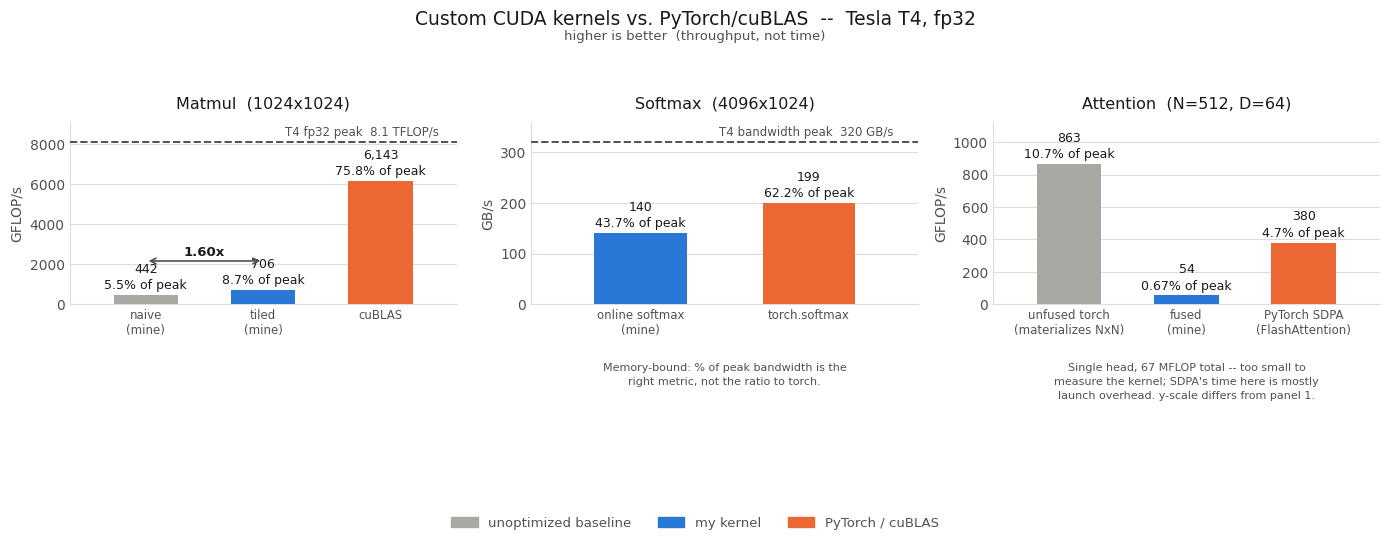


PASTE INTO README.md  (replaces the Results table)

| Kernel | My implementation | PyTorch / cuBLAS | % of T4 peak |
|---|---|---|---|
| Matmul, naive (1024x1024) | 4.860 ms (442 GFLOP/s) | — | 5.5% |
| Matmul, tiled (1024x1024) | 3.040 ms (706 GFLOP/s) | 0.350 ms (6143 GFLOP/s, cuBLAS) | 8.7% vs 75.8% |
| Softmax (4096x1024) | 0.240 ms (140 GB/s) | 0.168 ms (199 GB/s, torch) | 43.7% vs 62.2% of bandwidth |
| Attention (N=512, D=64) | 1.243 ms | 0.078 ms (unfused), 0.177 ms (SDPA) | see note |

**Tiled vs. naive matmul: 1.60x speedup** from shared-memory tiling alone.

> Note: at N=512, D=64, single head, the problem is only 67 MFLOP -- small enough that torch's *unfused* attention (0.078 ms) actually beats its fused SDPA path (0.177 ms), because dispatch costs more than the math. The fused kernel here is 16x slower than the unfused baseline it was written to beat. That gap is real, but this
> shape cannot measure it properly -- see 'Why cuBLAS and PyTorch are still faster'.

SANITY C

In [ ]:
import os
import matplotlib.pyplot as plt

# --- Tesla T4 hardware ceilings -------------------------------------------
FP32_PEAK_GFLOPS = 8100.0    # 2560 CUDA cores x 2 flop/clk x 1.59 GHz
MEM_PEAK_GBPS = 320.0        # GDDR6

# --- problem sizes ---------------------------------------------------------
# NOTE: cell 12 sets N = 1024 for the matmul, then cell 22 REBINDS N, D = 512, 64.
# By the time this cell runs N is 512, so the matmul size is spelled out
# explicitly here. Using the live N would understate matmul FLOPs by 8x.
MATMUL_N = 1024
SOFTMAX_ROWS, SOFTMAX_COLS = rows, cols
ATTN_N, ATTN_D = N, D        # these ARE the attention sizes at this point

matmul_gflop = 2.0 * MATMUL_N ** 3 / 1e9
softmax_gb = SOFTMAX_ROWS * SOFTMAX_COLS * 4 * 2 / 1e9   # read + write, fp32
attn_gflop = 2.0 * (2.0 * ATTN_N ** 2 * ATTN_D) / 1e9    # QK^T and PV

rate = lambda work, ms: work / (ms / 1000.0)

# --- palette ---------------------------------------------------------------
INK, INK_MUTED, GRID = "#1a1a19", "#52514e", "#dcdcd8"
C_BASE, C_MINE, C_LIB = "#a9a8a2", "#2a78d6", "#eb6834"

attn_bars = [("fused\n(mine)", rate(attn_gflop, attn_kernel_ms), C_MINE)]
try:  # torch's unfused attention -- the baseline the fused kernel exists to beat
    attn_bars.insert(0, ("unfused torch\n(materializes NxN)",
                         rate(attn_gflop, naive_ms), C_BASE))
except NameError:
    pass
attn_bars.append(("PyTorch SDPA\n(FlashAttention)", rate(attn_gflop, sdpa_ms), C_LIB))

PANELS = [
    dict(title=f"Matmul  ({MATMUL_N}x{MATMUL_N})", unit="GFLOP/s",
         peak=FP32_PEAK_GFLOPS, peak_label="T4 fp32 peak  8.1 TFLOP/s",
         bars=[("naive\n(mine)", rate(matmul_gflop, matmul_naive_ms), C_BASE),
               ("tiled\n(mine)", rate(matmul_gflop, matmul_tiled_ms), C_MINE),
               ("cuBLAS", rate(matmul_gflop, cublas_ms), C_LIB)],
         speedup=(0, 1, f"{matmul_naive_ms / matmul_tiled_ms:.2f}x"), note=None),

    dict(title=f"Softmax  ({SOFTMAX_ROWS}x{SOFTMAX_COLS})", unit="GB/s",
         peak=MEM_PEAK_GBPS, peak_label="T4 bandwidth peak  320 GB/s",
         bars=[("online softmax\n(mine)", rate(softmax_gb, softmax_kernel_ms), C_MINE),
               ("torch.softmax", rate(softmax_gb, softmax_ms), C_LIB)],
         speedup=None,
         note="Memory-bound: % of peak bandwidth is the\nright metric, not the ratio to torch."),

    # No roofline here on purpose -- against 8.1 TFLOP/s both bars would be
    # invisible slivers. True, but useless.
    dict(title=f"Attention  (N={ATTN_N}, D={ATTN_D})", unit="GFLOP/s",
         peak=None, peak_label=None, bars=attn_bars, speedup=None,
         note=(f"Single head, {attn_gflop * 1000:.0f} MFLOP total -- too small to\n"
               "measure the kernel; SDPA's time here is mostly\n"
               "launch overhead. y-scale differs from panel 1.")),
]


def draw_panel(ax, p):
    labels = [b[0] for b in p["bars"]]
    values = [b[1] for b in p["bars"]]
    colors = [b[2] for b in p["bars"]]
    xs = range(len(values))
    ax.bar(xs, values, width=0.55, color=colors, zorder=3)

    top = p["peak"] * 1.12 if p["peak"] else max(values) * 1.30
    ax.set_ylim(0, top)

    if p["peak"]:
        ax.axhline(p["peak"], ls="--", lw=1.4, color=INK_MUTED, zorder=4)
        ax.text(len(values) - 0.5, p["peak"] + top * 0.015, p["peak_label"],
                ha="right", va="bottom", fontsize=8.5, color=INK_MUTED)

    # Direct labels carry the absolute rate AND its share of the hardware
    # ceiling. The second line is the point: it says where we are on the
    # machine, not where we are relative to someone else's kernel.
    ceiling = p["peak"] or FP32_PEAK_GFLOPS
    for x, v in zip(xs, values):
        pct = 100.0 * v / ceiling
        txt = f"{pct:.1f}% of peak" if pct >= 1 else f"{pct:.2f}% of peak"
        ax.text(x, v + top * 0.018, f"{v:,.0f}\n{txt}", ha="center", va="bottom",
                fontsize=9, color=INK, linespacing=1.35)

    if p["speedup"]:
        i, j, text = p["speedup"]
        y = max(values[i], values[j]) + top * 0.16
        ax.annotate("", xy=(i, y), xytext=(j, y),
                    arrowprops=dict(arrowstyle="<->", color=INK_MUTED, lw=1.2))
        ax.text((i + j) / 2, y + top * 0.012, text, ha="center", va="bottom",
                fontsize=9.5, color=INK, fontweight="bold")

    if p["note"]:
        ax.text(0.5, -0.32, p["note"], transform=ax.transAxes, ha="center",
                va="top", fontsize=8, color=INK_MUTED, linespacing=1.5)

    ax.set_title(p["title"], fontsize=11.5, color=INK, pad=10)
    ax.set_ylabel(p["unit"], fontsize=10, color=INK_MUTED)
    ax.set_xticks(list(xs))
    ax.set_xticklabels(labels, fontsize=8.5, color=INK)
    ax.set_xlim(-0.65, len(values) - 0.35)
    ax.grid(axis="y", color=GRID, lw=0.8, zorder=0)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(GRID)
    ax.tick_params(colors=INK_MUTED, length=0)


fig, axes = plt.subplots(1, 3, figsize=(14, 5.4))
for ax, p in zip(axes, PANELS):
    draw_panel(ax, p)

fig.suptitle("Custom CUDA kernels vs. PyTorch/cuBLAS  --  Tesla T4, fp32",
             fontsize=13.5, color=INK, y=0.99)
fig.text(0.5, 0.935, "higher is better  (throughput, not time)",
         ha="center", fontsize=9.5, color=INK_MUTED)

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in (C_BASE, C_MINE, C_LIB)]
fig.legend(handles, ["unoptimized baseline", "my kernel", "PyTorch / cuBLAS"],
           loc="lower center", ncol=3, frameon=False, fontsize=9.5,
           labelcolor=INK_MUTED, bbox_to_anchor=(0.5, 0.005))

fig.tight_layout(rect=[0, 0.10, 1, 0.92])
os.makedirs("results", exist_ok=True)
fig.savefig("results/benchmark_comparison.png", dpi=160,
            bbox_inches="tight", facecolor="white")
plt.show()

# Emit the README table as markdown, ready to paste. Retyping numbers by hand
# is how a README drifts away from the code that produced it.
pk_f, pk_m = FP32_PEAK_GFLOPS, MEM_PEAK_GBPS
print("\n" + "=" * 68)
print("PASTE INTO README.md  (replaces the Results table)")
print("=" * 68 + "\n")
print("| Kernel | My implementation | PyTorch / cuBLAS | % of T4 peak |")
print("|---|---|---|---|")
print(f"| Matmul, naive ({MATMUL_N}x{MATMUL_N}) | {matmul_naive_ms:.3f} ms "
      f"({rate(matmul_gflop, matmul_naive_ms):.0f} GFLOP/s) | — | "
      f"{100 * rate(matmul_gflop, matmul_naive_ms) / pk_f:.1f}% |")
print(f"| Matmul, tiled ({MATMUL_N}x{MATMUL_N}) | {matmul_tiled_ms:.3f} ms "
      f"({rate(matmul_gflop, matmul_tiled_ms):.0f} GFLOP/s) | {cublas_ms:.3f} ms "
      f"({rate(matmul_gflop, cublas_ms):.0f} GFLOP/s, cuBLAS) | "
      f"{100 * rate(matmul_gflop, matmul_tiled_ms) / pk_f:.1f}% vs "
      f"{100 * rate(matmul_gflop, cublas_ms) / pk_f:.1f}% |")
print(f"| Softmax ({SOFTMAX_ROWS}x{SOFTMAX_COLS}) | {softmax_kernel_ms:.3f} ms "
      f"({rate(softmax_gb, softmax_kernel_ms):.0f} GB/s) | {softmax_ms:.3f} ms "
      f"({rate(softmax_gb, softmax_ms):.0f} GB/s, torch) | "
      f"{100 * rate(softmax_gb, softmax_kernel_ms) / pk_m:.1f}% vs "
      f"{100 * rate(softmax_gb, softmax_ms) / pk_m:.1f}% of bandwidth |")
_unfused = globals().get("naive_ms")
_ref = (f"{sdpa_ms:.3f} ms (SDPA)" if _unfused is None
        else f"{_unfused:.3f} ms (unfused), {sdpa_ms:.3f} ms (SDPA)")
print(f"| Attention (N={ATTN_N}, D={ATTN_D}) | {attn_kernel_ms:.3f} ms | {_ref} | "
      f"see note |")

print(f"\n**Tiled vs. naive matmul: {matmul_naive_ms / matmul_tiled_ms:.2f}x speedup** "
      "from shared-memory tiling alone.\n")
if _unfused:
    print(f"> Note: at N={ATTN_N}, D={ATTN_D}, single head, the problem is only "
          f"{attn_gflop * 1000:.0f} MFLOP -- small enough that torch's *unfused* "
          f"attention ({_unfused:.3f} ms) actually beats its fused SDPA path "
          f"({sdpa_ms:.3f} ms), because dispatch costs more than the math. The "
          f"fused kernel here is {attn_kernel_ms / _unfused:.0f}x slower than the "
          "unfused baseline it was written to beat. That gap is real, but this\n"
          "> shape cannot measure it properly -- see 'Why cuBLAS and PyTorch are "
          "still faster'.")

print("\n" + "=" * 68)
print("SANITY CHECK -- run the notebook twice and compare these two lines.")
print("If they disagree by more than a few percent the timing harness is still")
print("wrong and the numbers above should not be committed.")
print("=" * 68)
print(f"  matmul tiled {matmul_tiled_ms:.4f} ms | softmax {softmax_kernel_ms:.4f} ms "
      f"| attention {attn_kernel_ms:.4f} ms")


## Notes

The production baselines (cuBLAS, PyTorch's fused `scaled_dot_product_attention`) remain faster than these kernels, as expected — they use aggressive register blocking, vectorized loads, and Tensor Cores. The goal here is a from-scratch implementation of the core algorithms with honest measurement against those baselines.